In [2]:
%cd ..

/home/adam/projects/ega-bam-pipeline/analysis


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie ładnego stylu wykresów do publikacji
sns.set_theme(style="whitegrid")

# WCZYTANIE MACIERZY (Zakładamy, że pierwsza kolumna to ID pacjenta, stąd index_col=0)
df_old = pd.read_csv("data/genepy_matrix_v1.csv", index_col=0)
df_new = pd.read_csv("data/genepy_matrix_v2.csv", index_col=0)

# Oddzielenie etykiet (target) od samych genów
target = df_old['target'] # Zapisujemy target na boku
X_old = df_old.drop('target', axis=1)
X_new = df_new.drop('target', axis=1)

# Znalezienie genów, które występują w OBU macierzach (dla równego porównania)
common_genes = list(set(X_old.columns).intersection(set(X_new.columns)))
X_old = X_old[common_genes]
X_new = X_new[common_genes]

print(f"✅ Pomyślnie wczytano dane. Liczba pacjentów: {X_old.shape[0]}, Liczba wspólnych genów: {X_old.shape[1]}")

✅ Pomyślnie wczytano dane. Liczba pacjentów: 144, Liczba wspólnych genów: 61


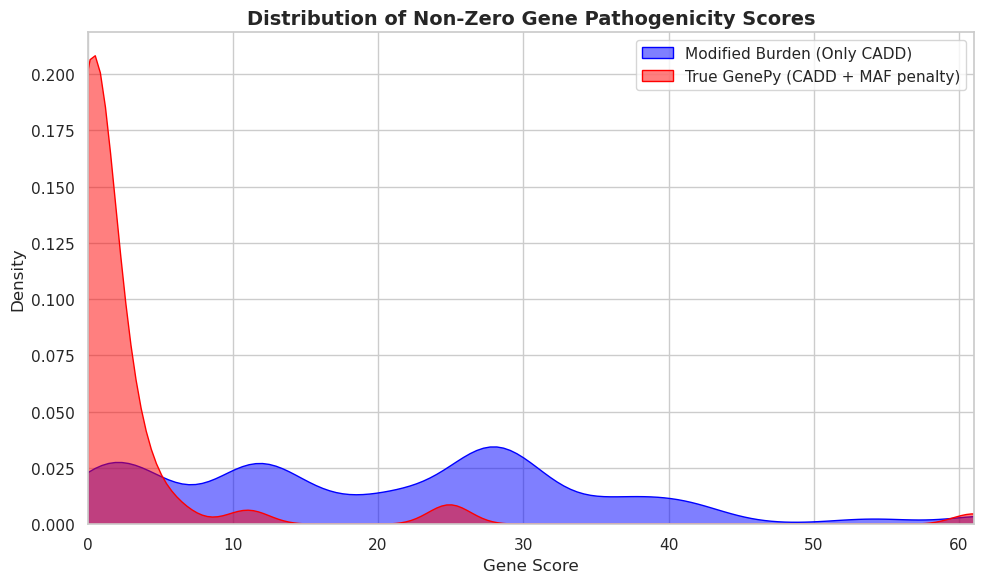

In [ ]:
plt.figure(figsize=(10, 6))

# Pobieramy tylko wartości większe od zera
vals_old = X_old.values.flatten()
vals_old = vals_old[vals_old > 0]

vals_new = X_new.values.flatten()
vals_new = vals_new[vals_new > 0]

# Rysujemy KDE (Krzywe gęstości)
sns.kdeplot(vals_old, fill=True, label="Modified Burden (Only CADD)", color="blue", alpha=0.5)
sns.kdeplot(vals_new, fill=True, label="True GenePy (CADD + MAF penalty)", color="red", alpha=0.5)

plt.title("Distribution of Non-Zero Gene Pathogenicity Scores", fontsize=14, fontweight='bold')
plt.xlabel("Gene Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()

# Ustawiamy limit osi X, żeby ignorować ekstremalne outliery i dobrze widzieć "brzuch" rozkładu
plt.xlim(0, np.percentile(vals_new, 99.5)) 
plt.tight_layout()
plt.show()

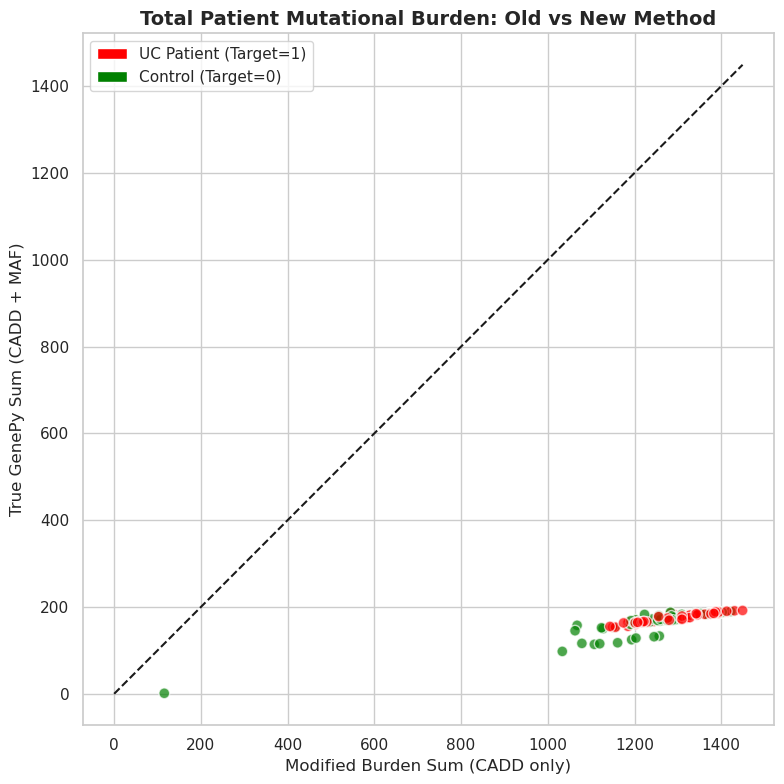

In [6]:
plt.figure(figsize=(8, 8))

# Bierzemy wspólną próbkę (np. pierwszy gen i pierwszych pacjentów), 
# ale najlepiej uśrednić wynik każdego pacjenta we wszystkich genach dla pokazania "Total Burden"
patient_burden_old = X_old.sum(axis=1)
patient_burden_new = X_new.sum(axis=1)

# Kolorujemy kropki na podstawie klasy (Chory vs Zdrowy)
colors = ['red' if t == 1 else 'green' for t in target]

plt.scatter(patient_burden_old, patient_burden_new, c=colors, alpha=0.7, edgecolors='w', s=60)

# Linia trendu idealnego (gdyby obie metody liczyły tak samo)
max_val = max(patient_burden_old.max(), patient_burden_new.max())
plt.plot([0, patient_burden_old.max()], [0, patient_burden_old.max()], 'k--', label="y = x (No Change)")

plt.title("Total Patient Mutational Burden: Old vs New Method", fontsize=14, fontweight='bold')
plt.xlabel("Modified Burden Sum (CADD only)", fontsize=12)
plt.ylabel("True GenePy Sum (CADD + MAF)", fontsize=12)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', edgecolor='w', label='UC Patient (Target=1)'),
                   Patch(facecolor='green', edgecolor='w', label='Control (Target=0)')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

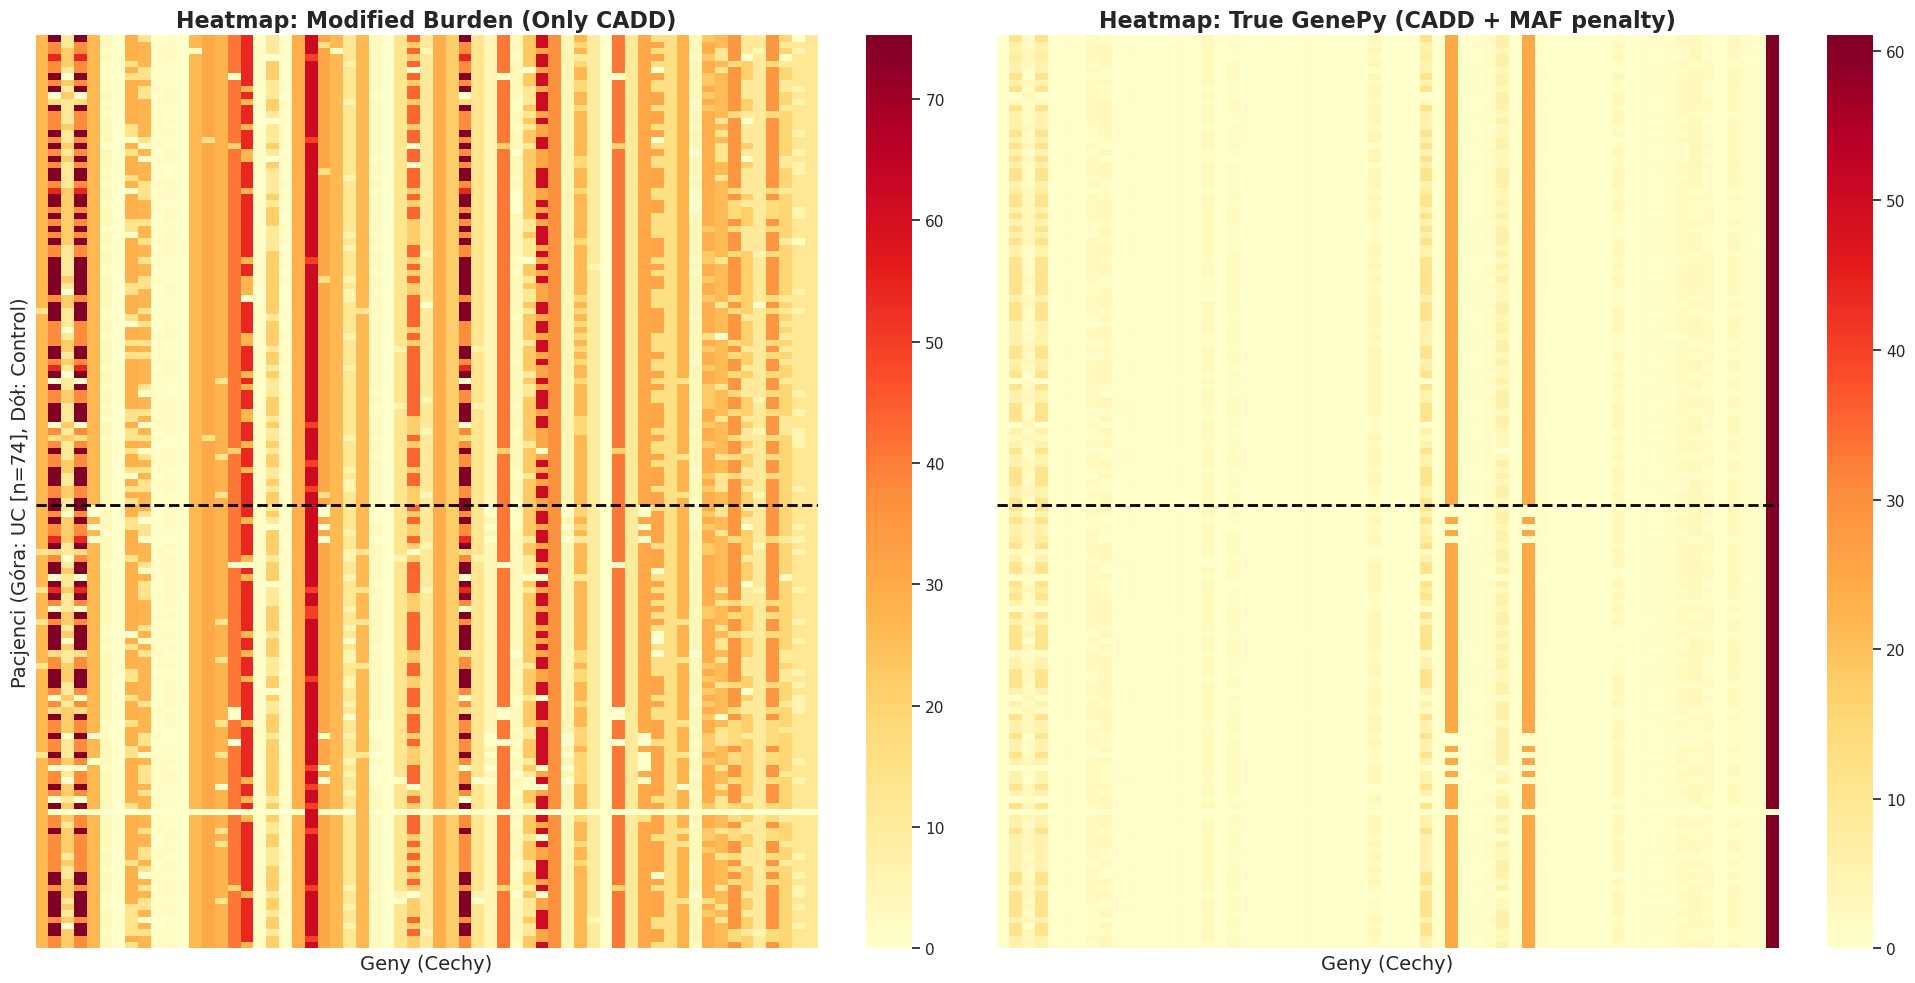

In [7]:
# --- KOMÓRKA 5: Heatmapy Macierzy (Stara vs Nowa) ---
import numpy as np

# 1. Przygotowanie danych - Sortujemy pacjentów, żeby UC (1) było na górze, a Control (0) na dole
df_old_sorted = X_old.copy()
df_old_sorted['target'] = target
df_old_sorted = df_old_sorted.sort_values(by='target', ascending=False)
y_sorted = df_old_sorted['target'] # Zapisujemy ułożenie etykiet
X_old_sorted = df_old_sorted.drop('target', axis=1)

df_new_sorted = X_new.copy()
df_new_sorted['target'] = target
df_new_sorted = df_new_sorted.sort_values(by='target', ascending=False)
X_new_sorted = df_new_sorted.drop('target', axis=1)

# Znalezienie indeksu (linii), gdzie kończą się pacjenci UC, a zaczynają zdrowi
uc_count = (y_sorted == 1).sum()

# 2. Obliczanie rozsądnego limitu kolorów (żeby ekstrema nie zepsuły palety)
vmax_old = np.percentile(X_old_sorted.values[X_old_sorted.values > 0], 99)
vmax_new = np.percentile(X_new_sorted.values[X_new_sorted.values > 0], 99)

# 3. Rysowanie wykresów
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Paleta YlOrRd (Yellow-Orange-Red) jest idealna: zera będą bardzo jasne/białe, a wysokie wartości czerwone
sns.heatmap(X_old_sorted, ax=axes[0], cmap="YlOrRd", cbar=True, 
            vmax=vmax_old, xticklabels=False, yticklabels=False)

# Dodajemy poziomą linię oddzielającą chorych od zdrowych
axes[0].axhline(uc_count, color='black', linewidth=2, linestyle='--')
axes[0].set_title("Heatmap: Modified Burden (Only CADD)", fontsize=16, fontweight='bold')
axes[0].set_ylabel(f"Pacjenci (Góra: UC [n={uc_count}], Dół: Control)", fontsize=14)
axes[0].set_xlabel("Geny (Cechy)", fontsize=14)

sns.heatmap(X_new_sorted, ax=axes[1], cmap="YlOrRd", cbar=True, 
            vmax=vmax_new, xticklabels=False, yticklabels=False)

# Pozioma linia separacji
axes[1].axhline(uc_count, color='black', linewidth=2, linestyle='--')
axes[1].set_title("Heatmap: True GenePy (CADD + MAF penalty)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Geny (Cechy)", fontsize=14)

plt.tight_layout()
plt.show()

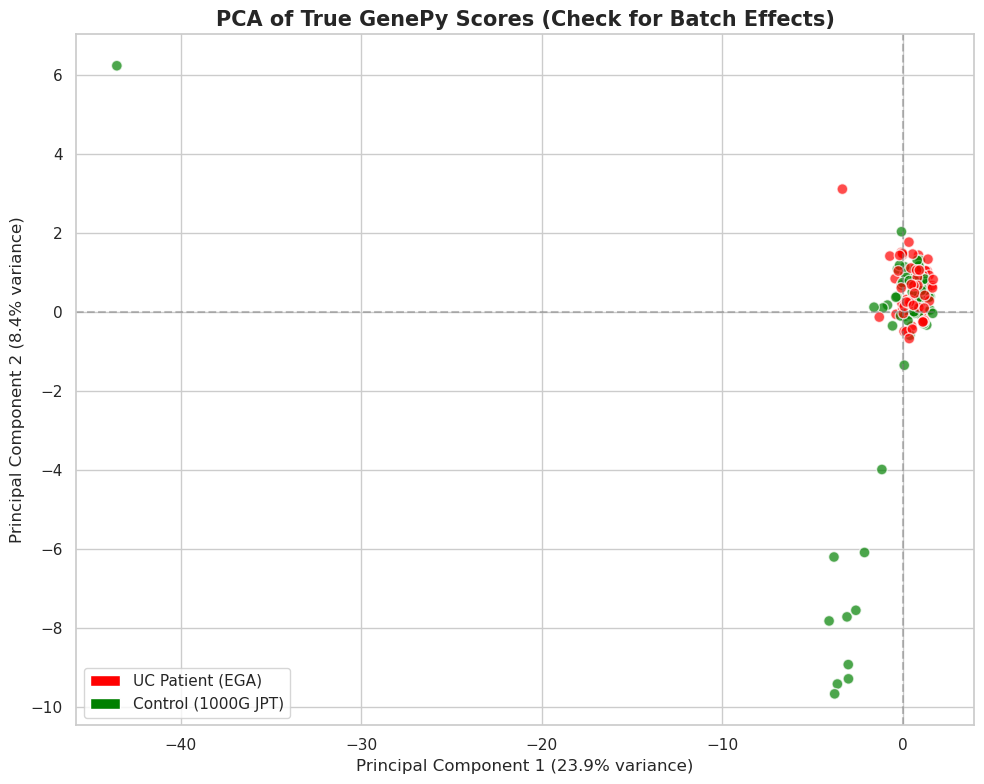

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standaryzacja danych (Kluczowe dla PCA, żeby geny o gigantycznych wartościach nie zdominowały wykresu)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new) # Używamy macierzy True GenePy

# 2. Obliczenie PCA dla 2 głównych składowych
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Wyciągnięcie procentu wyjaśnionej wariancji
var_explained = pca.explained_variance_ratio_ * 100

# 3. Rysowanie wykresu
plt.figure(figsize=(10, 8))
colors = ['red' if t == 1 else 'green' for t in target]

plt.scatter(principal_components[:, 0], principal_components[:, 1], 
            c=colors, alpha=0.7, edgecolors='w', s=60)

plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)

plt.title("PCA of True GenePy Scores (Check for Batch Effects)", fontsize=15, fontweight='bold')
plt.xlabel(f"Principal Component 1 ({var_explained[0]:.1f}% variance)", fontsize=12)
plt.ylabel(f"Principal Component 2 ({var_explained[1]:.1f}% variance)", fontsize=12)

# Legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', edgecolor='w', label='UC Patient (EGA)'),
                   Patch(facecolor='green', edgecolor='w', label='Control (1000G JPT)')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8515/1910581748.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Cohort', y='Active_Genes', data=df_qc, inner=None, palette={'UC (EGA)': 'lightcoral', 'Control (1000G)': 'lightgreen'})
/tmp/ipykernel_8515/1910581748.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cohort', y='Active_Genes', data=df_qc, width=0.2, boxprops={'zorder': 2}, palette={'UC (EGA)': 'red', 'Control (1000G)': 'green'})


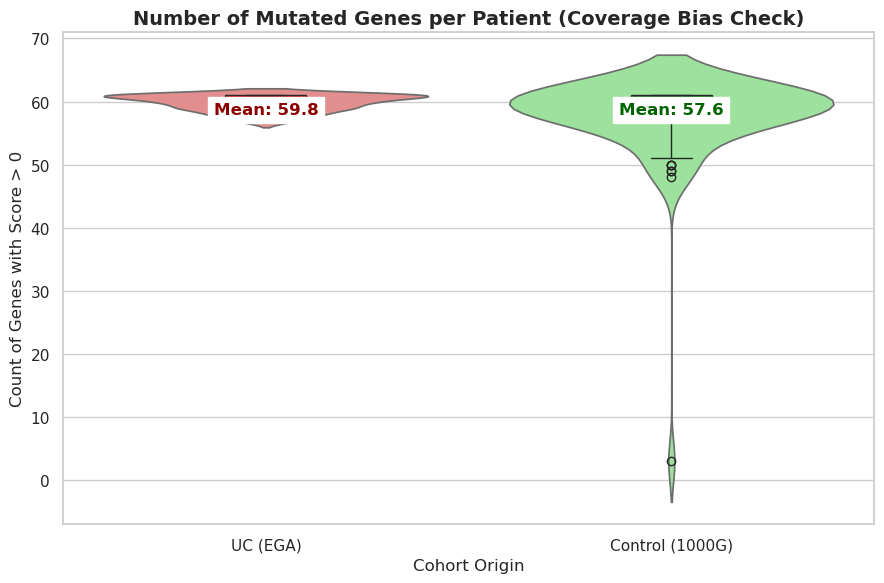

In [9]:
# 1. Zliczamy, ile genów ma wartość > 0 dla każdego pacjenta
non_zero_counts = (X_new > 0).sum(axis=1)

# Tworzymy mały DataFrame na potrzeby wykresu
df_qc = pd.DataFrame({
    'Active_Genes': non_zero_counts,
    'Cohort': ['UC (EGA)' if t == 1 else 'Control (1000G)' for t in target]
})

# 2. Rysowanie wykresu skrzypcowego (Violin Plot) i pudełkowego (Boxplot)
plt.figure(figsize=(9, 6))

# Używamy palette, żeby zachować spójność kolorystyczną (UC na czerwono, Control na zielono)
sns.violinplot(x='Cohort', y='Active_Genes', data=df_qc, inner=None, palette={'UC (EGA)': 'lightcoral', 'Control (1000G)': 'lightgreen'})
sns.boxplot(x='Cohort', y='Active_Genes', data=df_qc, width=0.2, boxprops={'zorder': 2}, palette={'UC (EGA)': 'red', 'Control (1000G)': 'green'})

plt.title("Number of Mutated Genes per Patient (Coverage Bias Check)", fontsize=14, fontweight='bold')
plt.ylabel("Count of Genes with Score > 0", fontsize=12)
plt.xlabel("Cohort Origin", fontsize=12)

# Dodanie statystyk do wykresu
uc_mean = df_qc[df_qc['Cohort'] == 'UC (EGA)']['Active_Genes'].mean()
ctrl_mean = df_qc[df_qc['Cohort'] == 'Control (1000G)']['Active_Genes'].mean()

plt.text(0, df_qc['Active_Genes'].max() * 0.95, f"Mean: {uc_mean:.1f}", ha='center', fontweight='bold', color='darkred', backgroundcolor='white')
plt.text(1, df_qc['Active_Genes'].max() * 0.95, f"Mean: {ctrl_mean:.1f}", ha='center', fontweight='bold', color='darkgreen', backgroundcolor='white')

plt.tight_layout()
plt.show()

Liczenie wariantów na pacjenta...


/tmp/ipykernel_8515/3993574962.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Original_Cohort', y='Total_Variants', data=df_qc, palette=['lightcoral', 'lightgreen'])
/tmp/ipykernel_8515/3993574962.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Technical_Batch', y='Total_Variants', data=df_qc, order=['Group A (Low)', 'Group B (Medium)', 'Group C (High)'], palette='Set2')


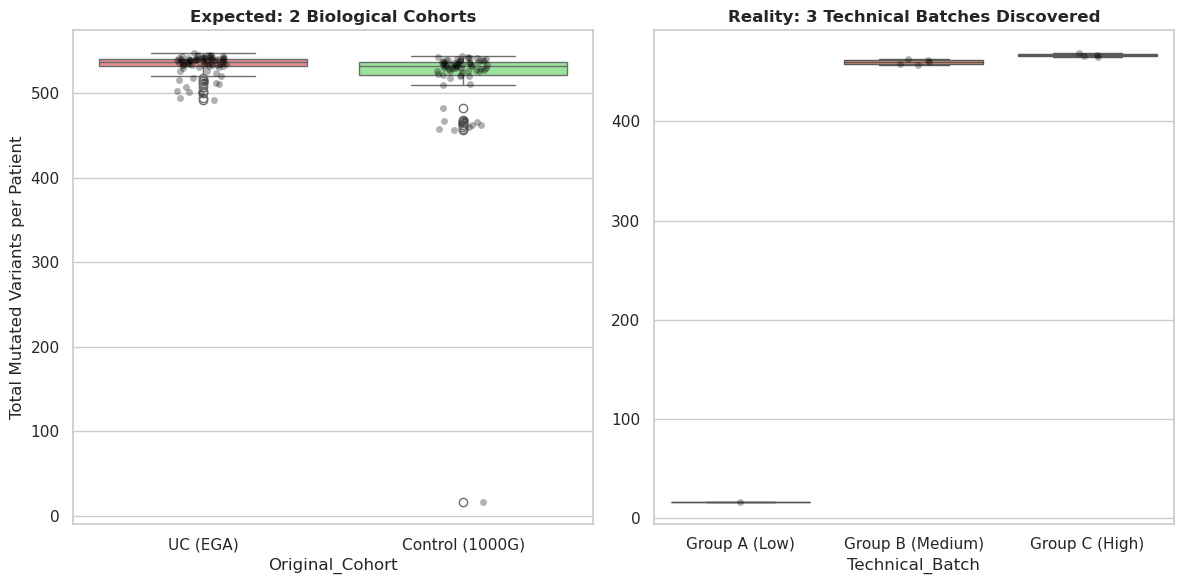

In [11]:
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Ścieżka do Twojego VCF (przed odfiltrowaniem złych próbek!)
VCF_FILE = "02_targeting/uc_vqsr_rare_included.vcf.gz"

print("Liczenie wariantów na pacjenta...")
variant_counts = {}

with gzip.open(VCF_FILE, 'rt') as f:
    for line in f:
        if line.startswith("##"):
            continue
        if line.startswith("#CHROM"):
            samples = line.strip().split('\t')[9:]
            variant_counts = {sample: 0 for sample in samples}
            continue
            
        cols = line.strip().split('\t')
        for i, sample_data in enumerate(cols[9:]):
            gt = sample_data.split(':')[0]
            # Zliczamy tylko mutacje (ignorujemy referencyjne 0/0 i braki danych ./.)
            if gt in ['0/1', '1/0', '1/1']:
                variant_counts[samples[i]] += 1

# Tworzenie DataFrame
df_qc = pd.DataFrame(list(variant_counts.items()), columns=['Sample', 'Total_Variants'])

# Oznaczanie oryginalnych 2 grup (na podstawie nazwy z 1000 Genomes)
df_qc['Original_Cohort'] = df_qc['Sample'].apply(lambda x: 'Control (1000G)' if '.mapped.ILLUMINA' in x else 'UC (EGA)')

# --- SZUKANIE "UKRYTEJ" TRZECIEJ GRUPY (Batch Effect) ---
# Używamy K-Means, żeby matematycznie podzielić próbki na 3 grupy na podstawie liczby wariantów
kmeans = KMeans(random_state=42)
df_qc['Cluster_3_Groups'] = kmeans.fit_predict(df_qc[['Total_Variants']])

# Sortowanie klastrów dla ładnego wyświetlania
cluster_means = df_qc.groupby('Cluster_3_Groups')['Total_Variants'].mean().sort_values().index
cluster_map = {cluster_means[0]: 'Group A (Low)', cluster_means[1]: 'Group B (Medium)', cluster_means[2]: 'Group C (High)'}
df_qc['Technical_Batch'] = df_qc['Cluster_3_Groups'].map(cluster_map)

# 2. Rysowanie "Dowodu Zbrodni" (Wykres Pudełkowy pokazujący Batch Effect)
plt.figure(figsize=(12, 6))

# Wykres 1: Jak to wyglądało w Twoich oczach (2 grupy medyczne)
plt.subplot(1, 2, 1)
sns.boxplot(x='Original_Cohort', y='Total_Variants', data=df_qc, palette=['lightcoral', 'lightgreen'])
sns.stripplot(x='Original_Cohort', y='Total_Variants', data=df_qc, color='black', alpha=0.3, jitter=True)
plt.title("Expected: 2 Biological Cohorts", fontsize=12, fontweight='bold')
plt.ylabel("Total Mutated Variants per Patient")

# Wykres 2: Jak to wyglądało naprawdę (3 grupy technologiczne)
plt.subplot(1, 2, 2)
sns.boxplot(x='Technical_Batch', y='Total_Variants', data=df_qc, order=['Group A (Low)', 'Group B (Medium)', 'Group C (High)'], palette='Set2')
sns.stripplot(x='Technical_Batch', y='Total_Variants', data=df_qc, order=['Group A (Low)', 'Group B (Medium)', 'Group C (High)'], color='black', alpha=0.3, jitter=True)
plt.title("Reality: 3 Technical Batches Discovered", fontsize=12, fontweight='bold')
plt.ylabel("")

plt.tight_layout()
plt.show()

In [18]:
import gzip
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Włączanie wyświetlania wykresów bezpośrednio w notebooku
%matplotlib inline

# --- CONFIGURATION ---
VCF_FILE = "03_harmonization/uc_targeted_DP5.vcf.gz" 

# Paleta kolorów identyczna z Twoimi oryginalnymi wykresami
palette_colors = {
    'Patient (UC)': '#1f77b4',   # Niebieski
    'Control (JPT)': '#2ca02c',  # Zielony
    'Other/Unknown': '#8c564b'   # Brązowy
}

In [19]:
print("Inicjalizacja i odczyt nagłówka...")
samples = []
sample_metrics = {}

with gzip.open(VCF_FILE, 'rt') as f:
    for line in f:
        if line.startswith("##"):
            continue
        if line.startswith("#CHROM"):
            samples = line.strip().split('\t')[9:]
            for s in samples:
                sample_metrics[s] = {'nHets': 0, 'total_depth': 0, 'called_variants': 0}
            break

print(f"Przetwarzanie {len(samples)} próbek z pliku VCF...")

with gzip.open(VCF_FILE, 'rt') as f:
    for idx, line in enumerate(f):
        if line.startswith("#"):
            continue
            
        cols = line.strip().split('\t')
        format_fields = cols[8].split(':')
        
        try:
            gt_idx = format_fields.index('GT')
            dp_idx = format_fields.index('DP') if 'DP' in format_fields else -1
        except ValueError:
            continue
            
        genotypes = cols[9:]
        
        for i, sample_data in enumerate(genotypes):
            sample_name = samples[i]
            data_split = sample_data.split(':')
            
            if len(data_split) <= max(gt_idx, dp_idx):
                continue
                
            gt = data_split[gt_idx]
            
            # 1. Zliczanie heterozygot
            if gt in ['0/1', '1/0']:
                sample_metrics[sample_name]['nHets'] += 1
                
            # 2. Sumowanie głębokości (DP)
            if dp_idx != -1:
                dp_val = data_split[dp_idx]
                if dp_val != '.' and dp_val.isdigit():
                    sample_metrics[sample_name]['total_depth'] += int(dp_val)
                    sample_metrics[sample_name]['called_variants'] += 1

        if idx % 50000 == 0 and idx > 0:
            print(f"Przetworzono {idx} pozycji genomowych...")

print("Zakończono parsowanie pliku VCF!")

Inicjalizacja i odczyt nagłówka...
Przetwarzanie 144 próbek z pliku VCF...
Przetworzono 50000 pozycji genomowych...
Przetworzono 100000 pozycji genomowych...
Przetworzono 150000 pozycji genomowych...
Przetworzono 200000 pozycji genomowych...
Przetworzono 250000 pozycji genomowych...
Przetworzono 300000 pozycji genomowych...
Przetworzono 350000 pozycji genomowych...
Przetworzono 400000 pozycji genomowych...
Przetworzono 450000 pozycji genomowych...
Przetworzono 500000 pozycji genomowych...
Przetworzono 550000 pozycji genomowych...
Przetworzono 600000 pozycji genomowych...
Przetworzono 650000 pozycji genomowych...
Przetworzono 700000 pozycji genomowych...
Przetworzono 750000 pozycji genomowych...
Zakończono parsowanie pliku VCF!


In [20]:
data_list = []
for s, metrics in sample_metrics.items():
    avg_depth = metrics['total_depth'] / metrics['called_variants'] if metrics['called_variants'] > 0 else 0
    data_list.append({
        'Sample': s,
        'nHets': metrics['nHets'],
        'avg_depth': avg_depth
    })

df = pd.DataFrame(data_list)

# Funkcja mapująca grupy
def get_group_name(name):
    if '.mapped.ILLUMINA.bwa.JPT.exome' in name:
        return 'Control (JPT)'
    elif 'UC_' in name:
        return 'Patient (UC)'
    else:
        return 'Other/Unknown'

df['Group'] = df['Sample'].apply(get_group_name)

# Podgląd tabeli w Jupyterze
df.head()

,Sample,nHets,avg_depth,Group
0,UC42_germline,2750,55.890125,Other/Unknown
1,UC18_germline,3988,16.976942,Other/Unknown
2,HCM-FFPE16_germline,16161,7.815320,Other/Unknown
3,UC28_germline,3568,40.203114,Other/Unknown
4,UC26_germline,3169,36.290981,Other/Unknown


/tmp/ipykernel_8515/2536945630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Group', y='avg_depth', palette=palette_colors, width=0.5)


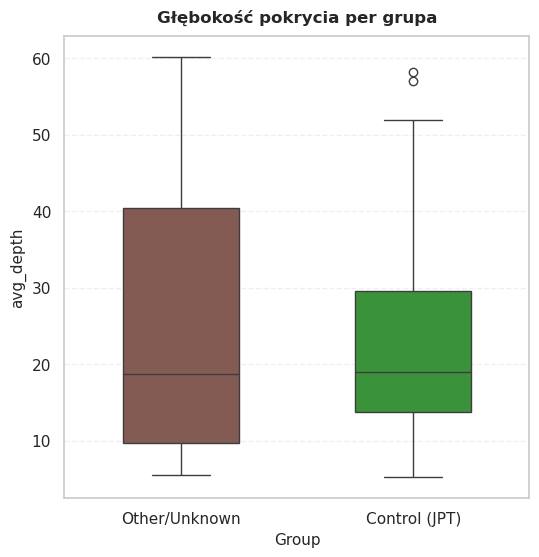

In [21]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='Group', y='avg_depth', palette=palette_colors, width=0.5)

plt.title('Głębokość pokrycia per grupa', fontsize=12, fontweight='bold', pad=10)
plt.ylabel('avg_depth', fontsize=11)
plt.xlabel('Group', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Zapis do pliku tekstowego/wektorowego do LaTeXa
plt.savefig('qc_avg_depth_reproduced.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_8515/2270150514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Group', y='nHets', palette=palette_colors, width=0.5)


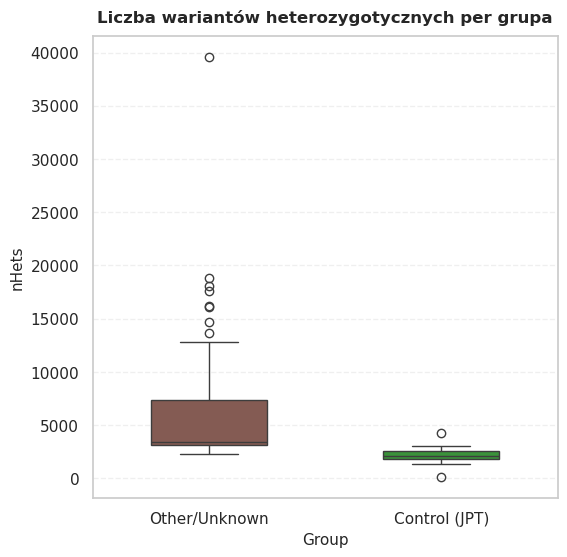

In [22]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='Group', y='nHets', palette=palette_colors, width=0.5)

plt.title('Liczba wariantów heterozygotycznych per grupa', fontsize=12, fontweight='bold', pad=10)
plt.ylabel('nHets', fontsize=11)
plt.xlabel('Group', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.savefig('qc_n_hets_reproduced.png', dpi=300, bbox_inches='tight')
plt.show()